## Implementing the XOR gate through evolutionary algorithms ##

The aim of this project is to implement a simple logic gate, the XOR gate, on a basic neural network, and to do so by means of evolutionary algorithms.
This work is mostly propaedeutic for the following project, which would be to use evolutionary algorithm to study the evolution of the basic computational cell, in order to verify if the neuron (i.e. a cell dedicated to computation, characterized by a threshold mechanic and a polarity) is the only possible solution achievable through evolution or if, instead, there are other possibility which haven't been explored. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pprint import pprint
import graph_tool as gt
from graph_tool.all import *
import copy

import network as n

# Set the seed for random generations
np.random.seed(12345)
plt.rcParams.update({
    'font.size': 24,
    'axes.titlesize': 24,
    'axes.labelsize': 20,
    'xtick.labelsize': 20,
    'ytick.labelsize': 20,
    'legend.fontsize': 24,
    'figure.titlesize': 24
})


(ipykernel_launcher.py:76921): dbind-WARNING **: 13:30:27.529: AT-SPI: Error retrieving accessibility bus address: org.freedesktop.DBus.Error.ServiceUnknown: The name org.a11y.Bus was not provided by any .service files


First of all, I'll briefly explain how the code is structured. It is divided between two files:
- network.py: contains
    - class Network: implements the network structure, with its basic attributes and methods.
    - function evolution(par): it's the evolutionary algorithm that searches the parameters space for the best network which implements the target gate.
- xor.ipynb (this file): here the simulation parameters are defined, the code is executed and the resulting data is briefly analyzed. 

In [2]:
# Define the set of parameters
par = {'Sk_range': [1,2,3,4,5],                  # define the possible value for S.
       'Theta_range': [-1,+1],                   # define the possible value for Theta.
       'J_range': [-1,+1],                       # define the possible value for J.
       'input_set':[[0,0],[0,1],[1,0],[1,1]],    # Set of inputs.
       'target_set': [0.0,1.0,1.0,0.0],          # set of outputs for the XOR gate .
       'mutation_ratio': 0.8,                    # rho: set the ratio of mutated solutions over the whole number of individuals that have to be generate after a selection. Who is not mutated is random 
       'S_mutation_radius': 1,                   # module of the mutation applied on S (when a mutation is applied).
       'Theta_mutation_radius': 0.1,             # standard deviation of the normal distribution used to sample the mutation value for Theta.
       'J_mutation_radius': 0.1,                 # standard deviation of the normal distribution used to sample the mutation value for J.
       'N_sol': 200,                             # Set the number of solutions.
       'n_iter': 1000,                          # Number of iterations of the algorithm.  
       'longLinks': False,                        # parameter of initJ(). default to True. If True, the input layer neurons can link directly to the output neuron. If false, they can link only to the hidden layer.
                                                 # This was added because the definition of NN would have layers only linked to the layers just before and after. 
       'n_early_stop': 1}                        # Maximum number of offsprings that are to be generated to trigger early stopping.

Now I'll present the Network class: this class is used to construct a basic neural network object, which in this project acts as the individual of the population that undergoes evolution. Each Network object is charcterized by some attributes:
- 2 input neurons, 1 output neurons.
- S intra neurons, organized in a single layer.
- A array Theta, containing the threshold values of each neuron.
- A weight matrix J. The element $J_{ij}$ refers to the link from neuron j to neuron i.
- A connectivity matrix C, which expresses the presence or absence of a link between two given neurons. It uses the same indexes convention as J.
- A loss value.
- An activation function, which is common to every Network object.

Note that both matrices J and C are symmetric, but since the links in the network are always forward-directioned, I actually consider just the lower triangle in both matrices. In the evolution algorithm I update also the higher triangle elements, but only for simplicity, since they're never considered. The algorithm would surely benefit in terms of performances if the two matrices would be kept always symmetric.

Next, I'll briefly explain the method Network.generate(par), which is used to generate a random Network object: this method randomly sets all the parameters mentioned above (except for the activation function, which is fixed). All the parameters are uniformly sampled from the respective range and the neurons are all set to zero. Moreover, the loss of the network is computed, using the apposite method. 

The search algorithm selects the individuals based on their loss value, which is defined as such:
$$
L(\Omega) = \frac{1}{N_I N}\sum^N_{k}\left[ \sum^{N_I}_I\alpha\left(O^T - O_k\right)_I^2 + S\left(\frac{\sum_{i,j} C_{i,j}}{2}\right)_I\right]
$$
where $\Omega$ is the set of the individuals, $N_I$ is the number of possible inputs to the network, in this case 4, S is the number of intra neurons, N the number of individuals. $O^T$ is the target output, while $O_k$ is the actual output, given input I. Finally, $\alpha$ is a factor used to weight the first term of the loss function and in this case was set to 50.

Note: even tough the loss function is named as such, the objective is to minimize it. It would maybe be more correct to call it 'error' function, maybe.

Lastly, I'll quickly present the evolutionary algorithm implemented:
1) **Generation**: Generate $N$ individuals, called 'solutions'.
2) **Evaluation**: Evaluate the loss value of each one of those solutions.
3) **Selection**: Discard the solutions whose loss is *above* the mean loss of the whole set of solutions.
4) **Extraction of parents**: Randomly choose $n$ parents from the remaining to generate offsprings from, where $n$ is set by the parameter 'mutation_ratio'.
5) **Mutation**: Generate for each parent an offspring by mutation of the parameters S, J, C and Theta.
6) **Random Generation**: Generate the remaining individuals to get back to the original population at point 2 by random generation.
7) Back to step 2. 

A couple of comments about this procedure: 
- the mutations to each parameter are either sampled from a gaussian distribution, having mean = 0 and standard deviation = 'Theta_mutation_radius' or 'J_mutation_radius', or from a uniform distribution for C and finally for S by sampling from the array [-1,0,+1] with respective probabilities of p=[0.2,0.6,0.2].
- at the end of the iteration, the new solutions set is formed by: 
    - original selected individuals whose loss whose equal or below average.
    - offspring generated by mutation from parents extracted from the above individuals.
    - randomly generated individuals.

In the following cell the algorithm is executed, using the above-defined parameters set, par. In standard output is printed number of generated offsprings at each 100 iterations.

In [3]:
sols, Lmeans, Svals, bestLvalues = n.evolution(par,verb=1,early_stop=True)   # if executed with verb=2, the number of children is printed each 10 iterations.

Iteration #0...
# of childs: 66
Iteration #100...
# of childs: 27
Convergence reached after 159 iterations.


Next, the mean loss value is plotted against the iteration. As can also be understood from the above output, the algorithm quickly (shortly before 100 iterations) reaches a low loss value. Then, if no early stopping is implemented, it oscillates around the solution; such oscillations are only due to the second term of the loss function (i.e. the cost).

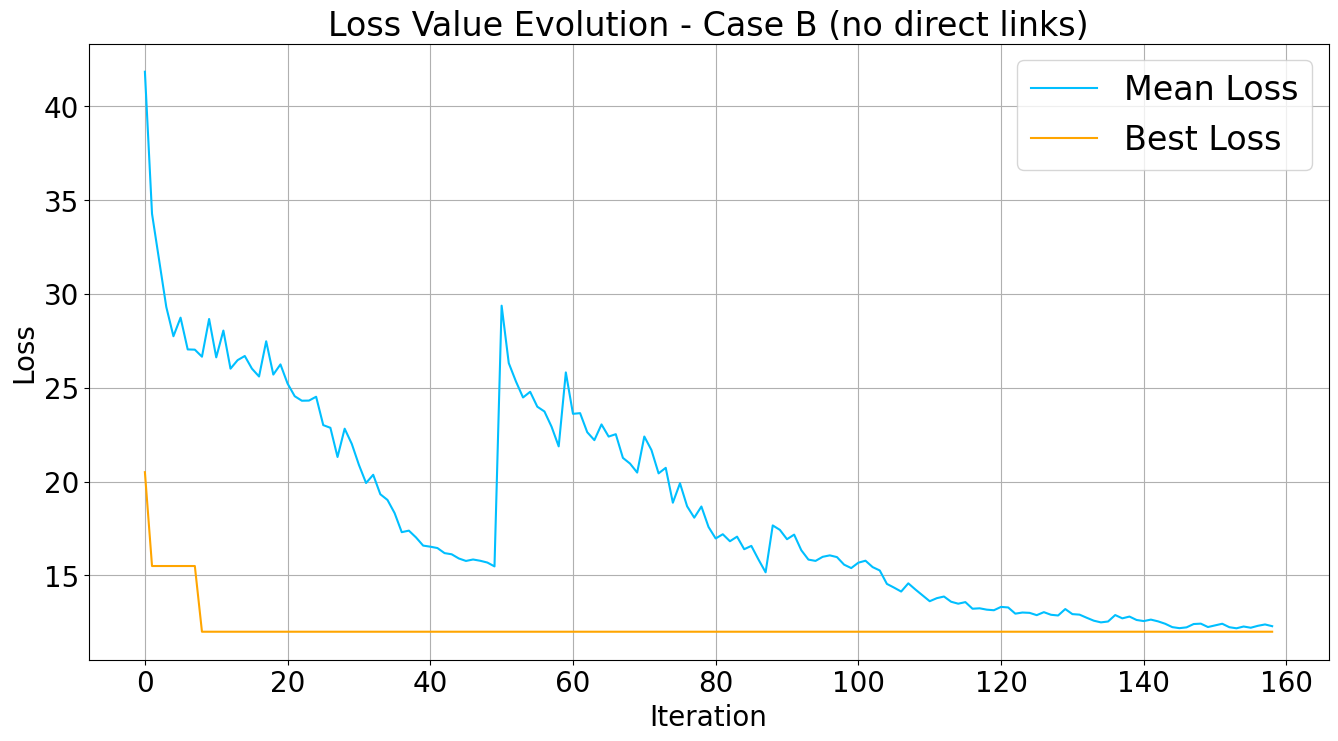

In [4]:
case = ['no direct links','direct links']
label = ['B','A']
plt.figure(figsize=(16,8))
plt.plot(Lmeans,c='deepskyblue',label='Mean Loss')
plt.plot(bestLvalues,c='orange',label='Best Loss')
plt.title(f'Loss Value Evolution - Case {label[par['longLinks']]} ({case[par['longLinks']]})')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.savefig(f'plots/lossPerceptron{label[par['longLinks']]}.png')
plt.show()

In [5]:
otherPar = copy.deepcopy(par)
otherPar['longLinks'] = not par['longLinks']
_, otherCase, _, otherBest = n.evolution(otherPar,verb=1,early_stop=True)  # compute the evolution for the other case (i.e. the case not executed in the cell above)

Iteration #0...
# of childs: 62
Iteration #100...
# of childs: 4
Iteration #200...
# of childs: 7
Convergence reached after 270 iterations.


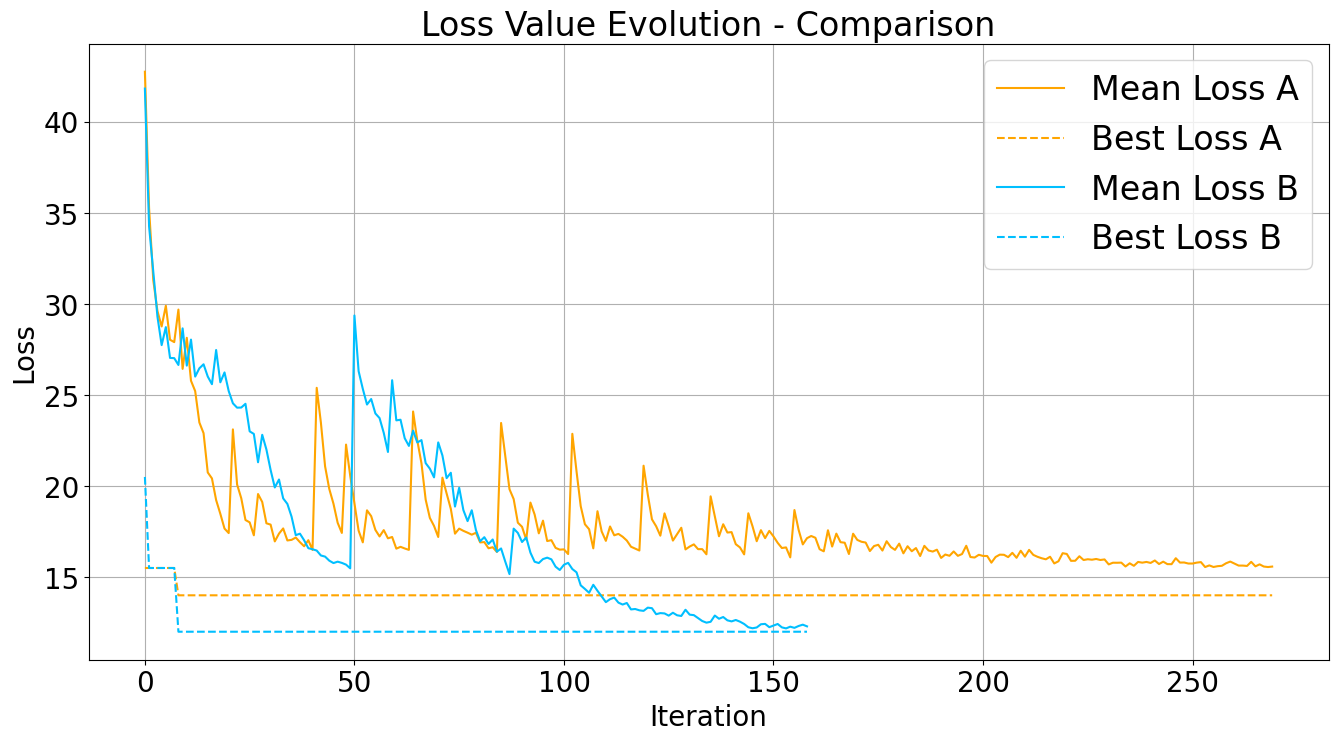

In [6]:
# Comparison case A and B
plt.figure(figsize=(16,8))
plt.plot(otherCase,c='orange',label=f'Mean Loss {label[not par['longLinks']]}')
plt.plot(otherBest,c='orange',label=f'Best Loss {label[not par['longLinks']]}',ls='--')
plt.plot(Lmeans,c='deepskyblue',label=f'Mean Loss {label[par['longLinks']]}')
plt.plot(bestLvalues,c='deepskyblue',label=f'Best Loss {label[par['longLinks']]}',ls='--')
plt.title(f'Loss Value Evolution - Comparison')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.savefig(f'plots/lossPerceptronVs.png')
plt.show()

Lastly, some parameters of the final solutions reached are printed in standard output. From these, some conclusions can be drawn:
- almost every generated solution implements the target logic gate (this can also be verified by executing the Netowrk.ff(input) method on any element of the solutions array).
- almost every solution can implement the gate with the usage of a single intra neuron.

C:[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0.]]
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0


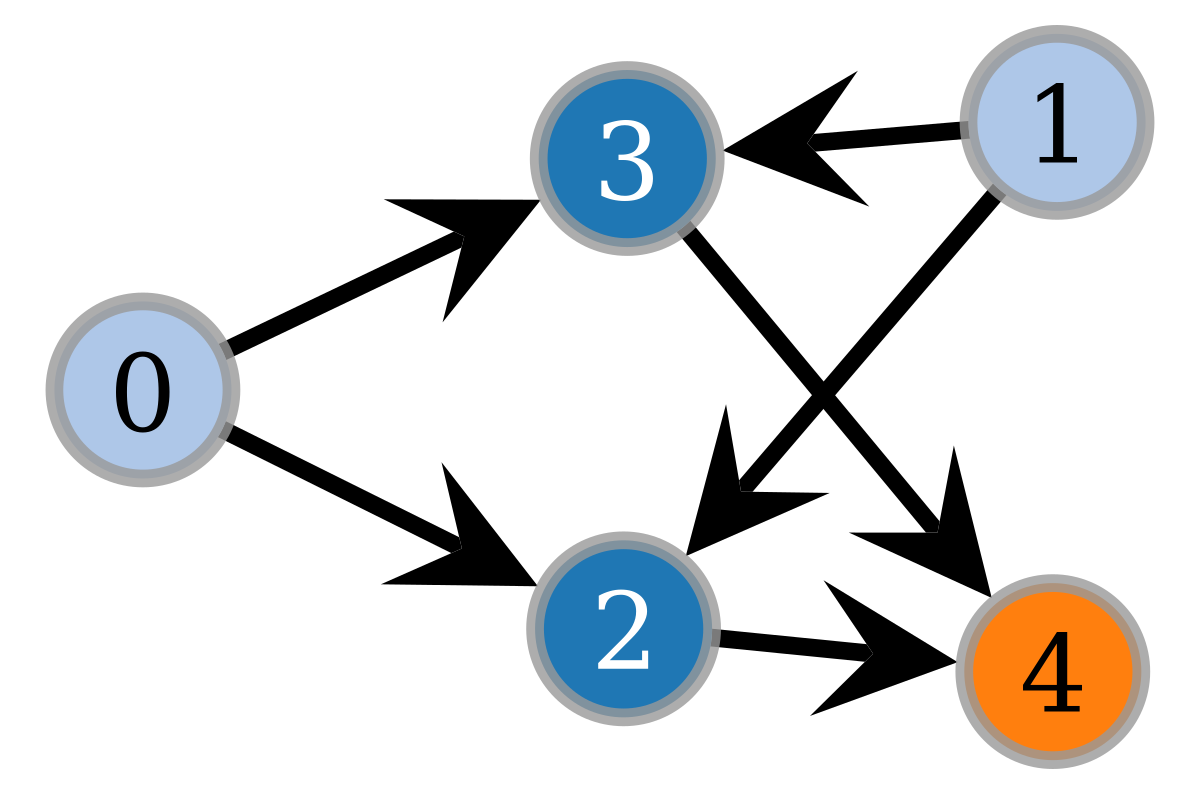

<VertexPropertyMap object with value type 'vector<double>', for Graph 0x7501b80ae570, at 0x7501b8136090>

In [7]:
from matplotlib.gridspec import GridSpec

best = sols[np.argmin([sol.loss for sol in sols])] # best solution
graph = Graph(np.column_stack(np.nonzero(best.C.T))) # I have to use the transpose of C because for graphtool C_ij is from i to j, while I'm using the opposite convention
print(f'C:{best.C}')
for input in par['input_set']:
    print(f'{input} Output: {best.ff(input)}')

highlight = graph.new_vertex_property('int')
highlight[graph.vertex(0)] = 1      
highlight[graph.vertex(1)] = 1
highlight[graph.vertex(len(best.C)-1)] = 2

graph_draw(
    graph,
    vorder=graph.vertex_index,
    vertex_text=graph.vertex_index,
    vertex_fill_color=highlight,
    #vcmap=plt.cm.Set1,
    edge_color='black',
    bg_color='white',
    output_size=(600,800)
)

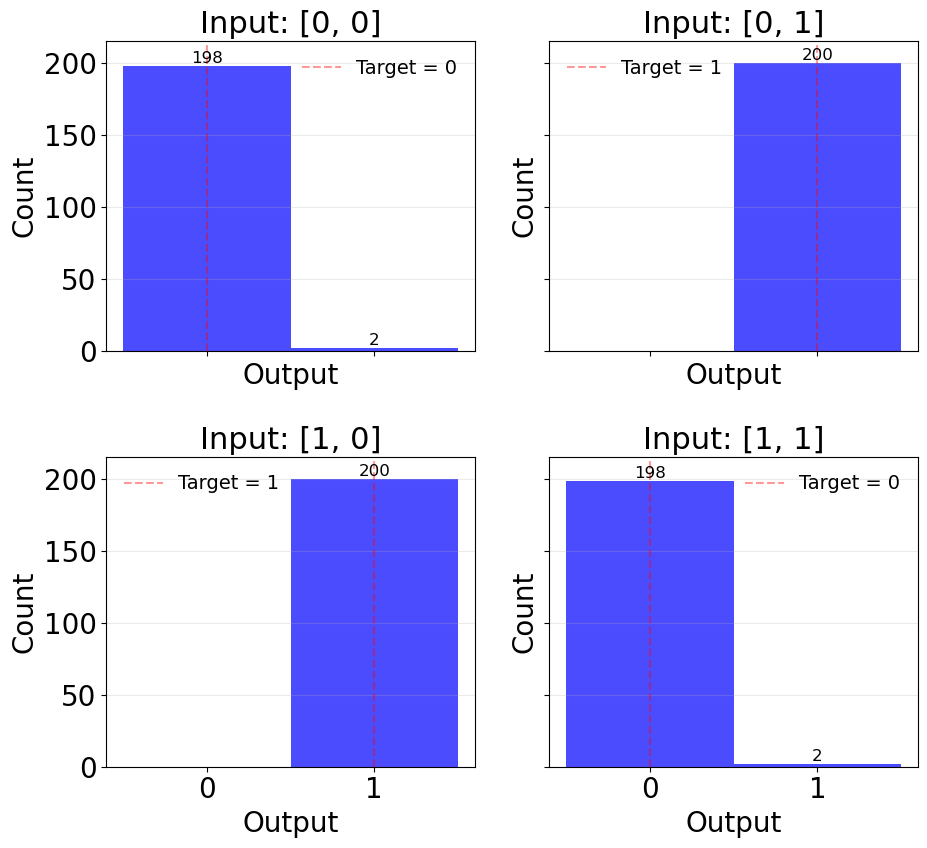

In [12]:
outputs = np.array([[sol.ff(inp) for inp in par['input_set']] for sol in sols], dtype=float)

n_inputs = len(par['input_set'])
n_cols = 2
n_rows = int(np.ceil(n_inputs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows),sharey=True,sharex=True)

axes = np.atleast_1d(axes).ravel()
for i, ax in enumerate(axes):
    ax.hist(outputs[:, i], bins=[-0.5, 0.5, 1.5], alpha=0.7, color='b')
    ax.set_title(f'Input: {par["input_set"][i]}',fontsize=22)
    ax.set_xlabel('Output')
    ax.set_ylabel('Count')
    ax.set_ylim([0,215])
    ax.set_xticks([0,1])
    ax.grid(axis='y', alpha=0.25)
    ax.axvline(par['target_set'][i], label=f'Target = {int(par['target_set'][i])}', color='r', linestyle='--',alpha=0.4)
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:
            ax.annotate(f'{int(height)}',
                        (patch.get_x() + patch.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=12)
    ax.legend(frameon=False,fontsize=14)

plt.tight_layout(rect=[0, 0, 0.7, 1])
plt.savefig('plots/IO.png')
plt.show()
plt.close(fig)

In [ ]:
print(f'Final mean loss: {Lmeans[-1]}')
for i,sol in enumerate(sols):
    print(f'Solution #{i}...')
    print(f'Loss: {sol.loss}')
    print(f'S: {sol.S}')
    for input in par['input_set']:
        print(f'{input} Output: {sol.ff(input)}')

Final mean loss: 12.295
Solution #0...
Loss: 12.0
S: 2
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #1...
Loss: 12.0
S: 2
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #2...
Loss: 12.0
S: 2
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #3...
Loss: 12.0
S: 2
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #4...
Loss: 12.0
S: 2
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #5...
Loss: 12.0
S: 2
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #6...
Loss: 12.0
S: 2
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #7...
Loss: 12.0
S: 2
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #8...
Loss: 12.0
S: 2
[0, 0] Output: 0.0
[0, 1] Output: 1.0
[1, 0] Output: 1.0
[1, 1] Output: 0.0
Solution #9..

In [ ]:
for i,sol in enumerate(sols[0:10]):
    print(f'Solution #{i}...')
    print(sol.C)

Solution #0...
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0.]]
Solution #1...
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0.]]
Solution #2...
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0.]]
Solution #3...
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0.]]
Solution #4...
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0.]]
Solution #5...
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0.]]
Solution #6...
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0.]]
Solution #7...
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0.]]
Solution #8...
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [1. 1. 0. 0. 0.]
 [0. 0. 1. 1. 0.]]
Solution #9...
[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0.